In [1]:
# # !pip install scikit-learn nltk pandas matplotlib

import pandas as pd
import numpy as np
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sachi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sachi\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\sachi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
corpus = [
    "The cat sat on the mat.",
    "The dog played with the cat.",
    "Dogs and cats are great pets.",
    "I love my pet dog and my pet cat."
]

df = pd.DataFrame({'text': corpus})
df

,text
0,The cat sat on the mat.
1,The dog played with the cat.
2,Dogs and cats are great pets.
3,I love my pet dog and my pet cat.


In [3]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)          # remove punctuation/numbers
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess_text)
df

,text,clean_text
0,The cat sat on the mat.,cat sat mat
1,The dog played with the cat.,dog played cat
2,Dogs and cats are great pets.,dog cat great pet
3,I love my pet dog and my pet cat.,love pet dog pet cat


In [4]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
bow_matrix = cv.fit_transform(df['clean_text'])

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f"Doc{i+1}" for i in range(len(df))]
)

print("Vocabulary:", cv.vocabulary_)
bow_df

Vocabulary: {'cat': 0, 'sat': 7, 'mat': 4, 'dog': 1, 'played': 6, 'great': 2, 'pet': 5, 'love': 3}


,cat,dog,great,love,mat,pet,played,sat
Doc1,1,0,0,0,1,0,0,1
Doc2,1,1,0,0,0,0,1,0
Doc3,1,1,1,0,0,1,0,0
Doc4,1,1,0,1,0,2,0,0


In [5]:
# Each row = a document, each column = a word, each cell = word frequency
print("Shape of BoW matrix:", bow_matrix.shape)
print("\nTotal occurrences of each word across corpus:")
print(bow_df.sum().sort_values(ascending=False))

Shape of BoW matrix: (4, 8)

Total occurrences of each word across corpus:
cat       4
dog       3
pet       3
great     1
love      1
mat       1
played    1
sat       1
dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out(),
    index=[f"Doc{i+1}" for i in range(len(df))]
)

tfidf_df.round(3)

,cat,dog,great,love,mat,pet,played,sat
Doc1,0.346,0.000,0.000,0.00,0.663,0.000,0.000,0.663
Doc2,0.403,0.492,0.000,0.00,0.000,0.000,0.772,0.000
Doc3,0.344,0.421,0.659,0.00,0.000,0.520,0.000,0.000
Doc4,0.256,0.313,0.000,0.49,0.000,0.773,0.000,0.000


In [7]:
import math
from collections import Counter

def compute_tf(doc_tokens):
    tf_dict = {}
    total_terms = len(doc_tokens)
    counts = Counter(doc_tokens)
    for word, count in counts.items():
        tf_dict[word] = count / total_terms
    return tf_dict

def compute_idf(all_docs_tokens):
    N = len(all_docs_tokens)
    idf_dict = {}
    all_words = set(word for doc in all_docs_tokens for word in doc)
    for word in all_words:
        containing_docs = sum(1 for doc in all_docs_tokens if word in doc)
        idf_dict[word] = math.log(N / containing_docs) + 1  # smoothed
    return idf_dict

tokenized_docs = [doc.split() for doc in df['clean_text']]
idf_scores = compute_idf(tokenized_docs)

print("Manual IDF scores:")
for word, score in sorted(idf_scores.items(), key=lambda x: -x[1]):
    print(f"{word}: {score:.4f}")

Manual IDF scores:
love: 2.3863
sat: 2.3863
mat: 2.3863
played: 2.3863
great: 2.3863
pet: 1.6931
dog: 1.2877
cat: 1.0000


In [8]:
def get_top_words(doc_index, top_n=3):
    row = tfidf_df.iloc[doc_index]
    return row.sort_values(ascending=False).head(top_n)

for i in range(len(df)):
    print(f"\nTop words in Doc{i+1}:")
    print(get_top_words(i))


Top words in Doc1:
mat    0.663385
sat    0.663385
cat    0.346182
Name: Doc1, dtype: float64

Top words in Doc2:
played    0.771579
dog       0.492489
cat       0.402642
Name: Doc2, dtype: float64

Top words in Doc3:
great    0.659191
pet      0.519714
dog      0.420753
Name: Doc3, dtype: float64

Top words in Doc4:
pet     0.772535
love    0.489931
dog     0.312717
Name: Doc4, dtype: float64


<Figure size 1000x600 with 0 Axes>

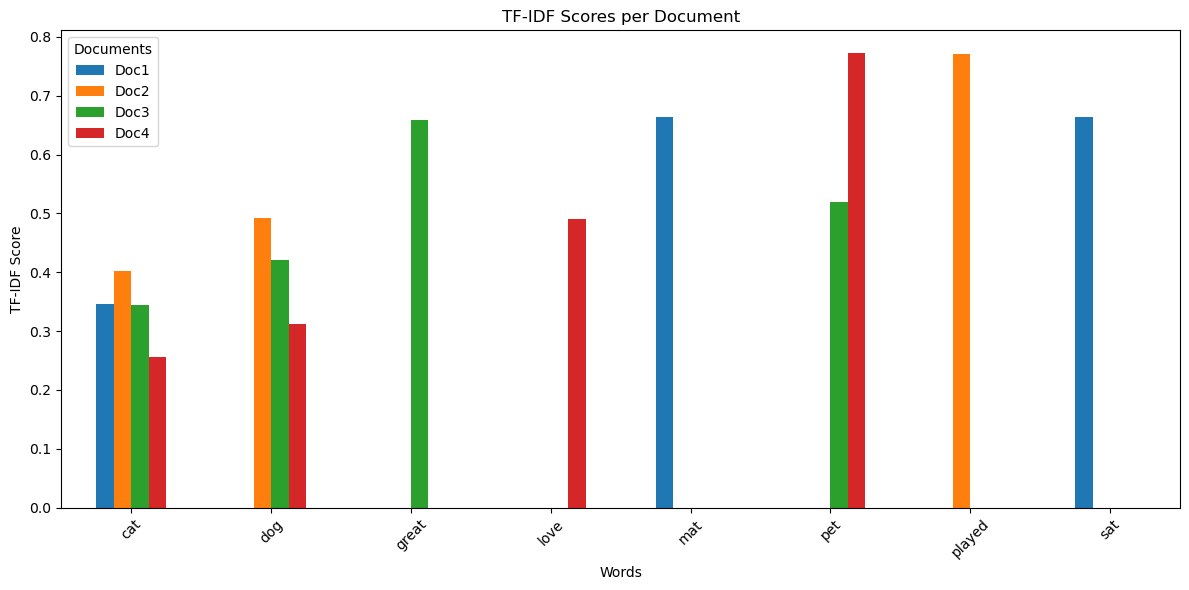

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
tfidf_df.T.plot(kind='bar', figsize=(12, 6))
plt.title("TF-IDF Scores per Document")
plt.ylabel("TF-IDF Score")
plt.xlabel("Words")
plt.xticks(rotation=45)
plt.legend(title="Documents")
plt.tight_layout()
plt.show()